## Exploration des données

#### Récupération et intégration des données dans un dataframe

In [133]:
import os
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [134]:
def read_file(file_path,type='RGB'):
    # Open the image file
    with Image.open(file_path) as img:
        # Convert the image to RGB (in case it's in a different format)
        img = img.convert(type)
        # Convert the image to a NumPy array
        img_array = np.array(img)

    return img_array

def visualize_image(image):
    if isinstance(image, np.ndarray):
        img = Image.fromarray(image)
    elif isinstance(image, Image.Image):
        img = image  # Déjà un PIL.Image
    else:
        raise ValueError("L'entrée doit être un numpy.ndarray ou un PIL.Image")
    img.show()

def recup_fichier(chemin):
    records = []

    for dirpath, dirnames, filenames in os.walk(chemin):
        parent_folder = os.path.basename(dirpath)
        for fichier in filenames:
            chemin_complet = os.path.join(dirpath, fichier)
            img_array = read_file(chemin_complet)
            h, w = img_array.shape[:2]
            records.append({
                'Class': parent_folder,
                'Nom_img': fichier,
                'img': img_array,
                'Hauteur': h,
                'Largeur': w,
                })

    df = pd.DataFrame(records)
    return df

path_folder = 'dataset'
BD = recup_fichier(path_folder)


In [135]:
BD.head()

,Class,Nom_img,img,Hauteur,Largeur
0,Abrasions,abrasions (1).jpg,"[[[201, 174, 144], [201, 174, 144], [199, 172,...",640,640
1,Abrasions,abrasions (10).jpg,"[[[153, 212, 230], [153, 212, 230], [153, 212,...",640,640
2,Abrasions,abrasions (11).jpg,"[[[164, 127, 121], [164, 127, 121], [164, 127,...",640,640
3,Abrasions,abrasions (12).jpg,"[[[205, 181, 177], [205, 181, 177], [205, 181,...",640,640
4,Abrasions,abrasions (13).jpg,"[[[181, 183, 198], [181, 183, 198], [181, 183,...",640,640


#### Equilibrage des classes

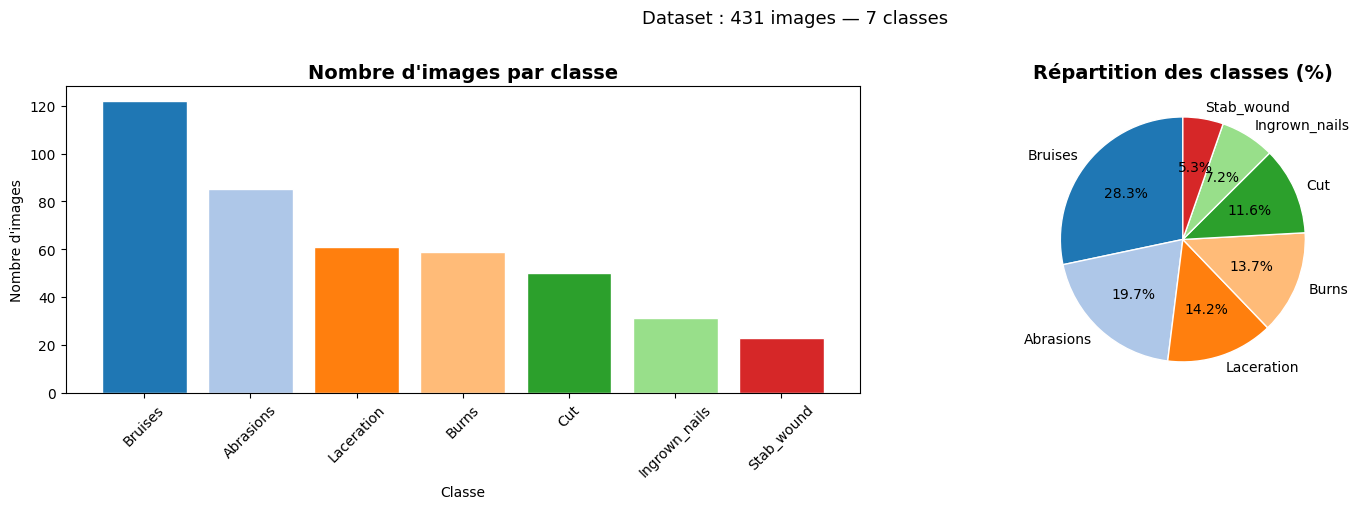

In [136]:
count_by_class = BD['Class'].value_counts().sort_values(ascending=False)
n_classes = len(count_by_class)
total_imgs = len(BD)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Barplot ---
colors = sns.color_palette('tab20', n_classes)
bars = axes[0].bar(count_by_class.index, count_by_class.values, color=colors, edgecolor='white')
axes[0].set_title('Nombre d\'images par classe', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'images')
axes[0].tick_params(axis='x', rotation=45)


# --- Pie ---
axes[1].pie(count_by_class.values, labels=count_by_class.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Répartition des classes (%)', fontsize=14, fontweight='bold')

plt.suptitle(f'Dataset : {total_imgs} images — {n_classes} classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Taille des images

In [137]:
# Résumé
print('\n📐 Statistiques des dimensions :')
print(BD[['Largeur', 'Hauteur']].describe().round(1).to_string())

# Tailles uniques
tailles_uniques = BD.groupby(['Hauteur', 'Largeur']).size().reset_index(name='count')
print(f"\n   • Nombre de résolutions distinctes : {len(tailles_uniques)}")
if len(tailles_uniques) == 1:
    print(f"   ✅ Toutes les images ont la même résolution : {tailles_uniques.iloc[0]['Largeur']}x{tailles_uniques.iloc[0]['Hauteur']}")
else:
    print(f"   ⚠️  Les images n'ont pas toutes la même résolution. Un redimensionnement sera nécessaire avant l'entraînement.")
    print(tailles_uniques.sort_values('count', ascending=False).head(10))


📐 Statistiques des dimensions :
       Largeur  Hauteur
count    431.0    431.0
mean     640.0    640.0
std        0.0      0.0
min      640.0    640.0
25%      640.0    640.0
50%      640.0    640.0
75%      640.0    640.0
max      640.0    640.0

   • Nombre de résolutions distinctes : 1
   ✅ Toutes les images ont la même résolution : 640x640


#### Visualisation par classe 

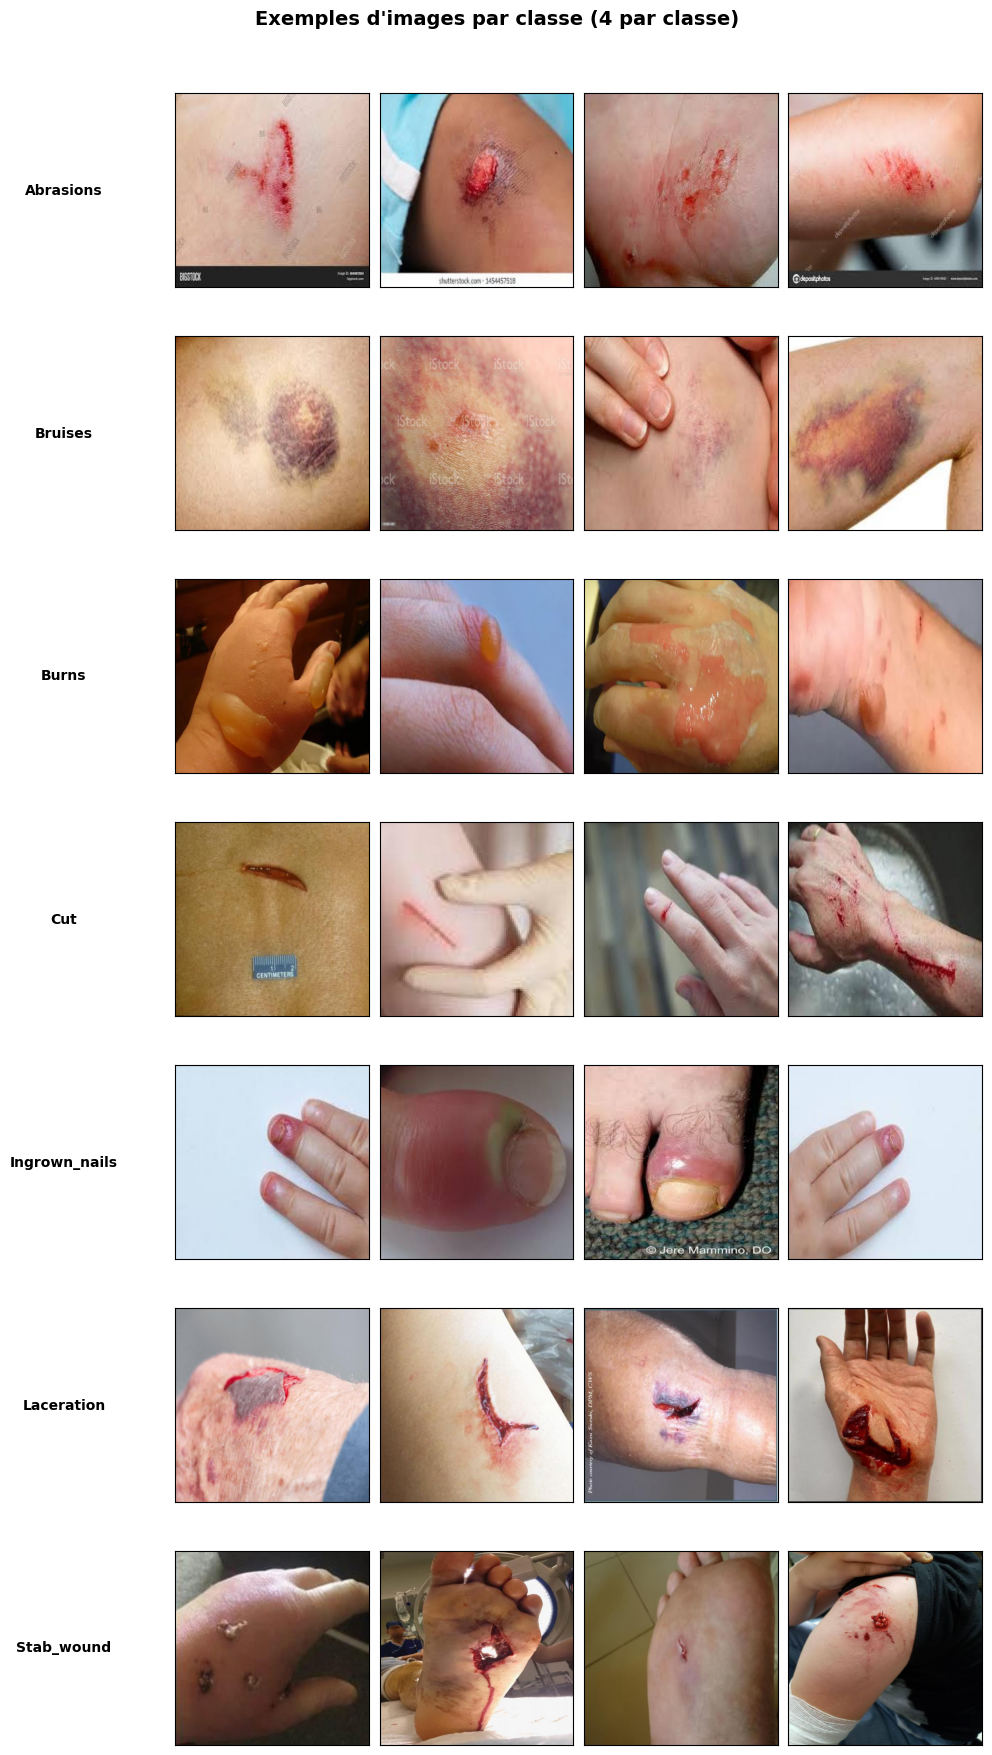

In [138]:
N_SAMPLES = 4 
list_class = BD['Class'].unique().tolist()

fig, axes = plt.subplots(n_classes , N_SAMPLES, figsize=(N_SAMPLES * 2.5, n_classes  * 2.5))

for row_idx, cls in enumerate(list_class):
    imgs_cls = BD[BD['Class'] == cls]['img'].tolist()
    sample_imgs = imgs_cls[:N_SAMPLES]

    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx, col_idx]
        pil_img = Image.fromarray(sample_imgs[col_idx])
        ax.imshow(np.array(pil_img))
        ax.set_xticks([])
        ax.set_yticks([])

        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0,
                          labelpad=80, va='center')

plt.suptitle(f'Exemples d\'images par classe ({N_SAMPLES} par classe)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Analyse des canaux RGB (histogrammes de couleur)

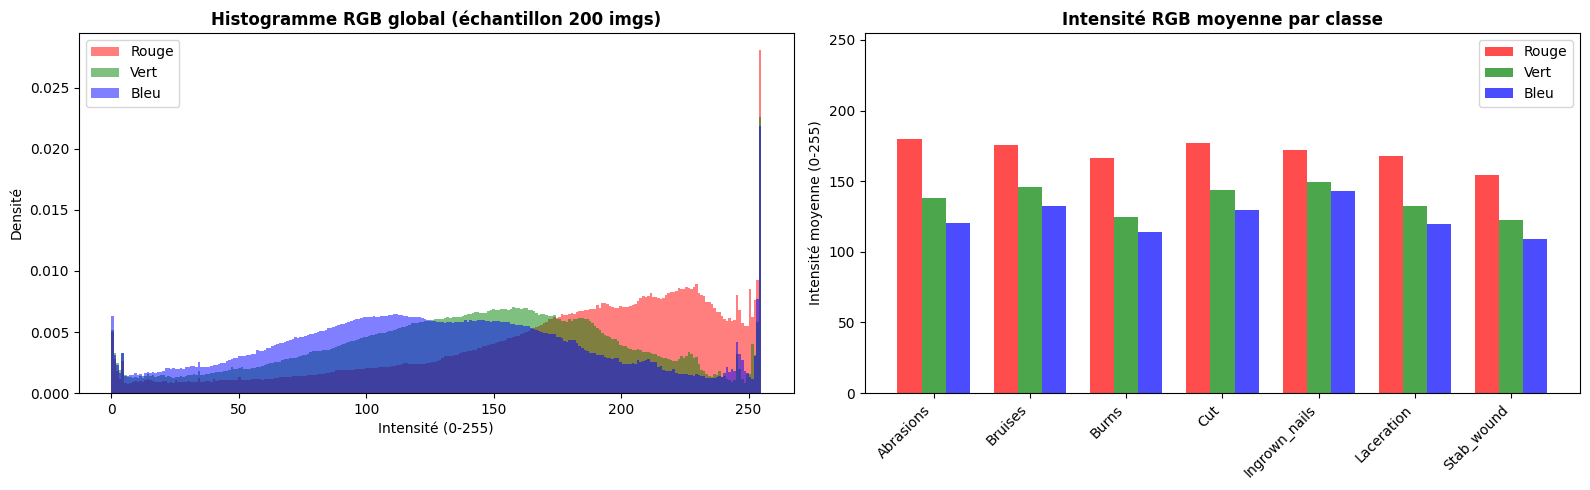

Moyenne RGB par classe
        Class     R_mean     G_mean     B_mean
    Abrasions 179.872863 138.205448 120.134018
      Bruises 175.624882 146.100405 132.728709
        Burns 166.726541 124.551726 114.198506
          Cut 177.089848 144.053233 129.402866
Ingrown_nails 172.143585 149.423228 143.132943
   Laceration 167.696880 132.621955 119.616559
   Stab_wound 154.644446 122.698863 109.351986


In [139]:
# Histogramme RGB global (sur un échantillon pour aller plus vite)
MAX_IMGS = 200
sample_df = BD.sample(MAX_IMGS, random_state=42)

r_vals, g_vals, b_vals = [], [], []
for img_arr in sample_df['img']:
    if img_arr.ndim == 3 and img_arr.shape[2] == 3:
        r_vals.append(img_arr[:, :, 0].flatten())
        g_vals.append(img_arr[:, :, 1].flatten())
        b_vals.append(img_arr[:, :, 2].flatten())

r_all = np.concatenate(r_vals)
g_all = np.concatenate(g_vals)
b_all = np.concatenate(b_vals)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Histogramme global superposé ---
axes[0].hist(r_all, bins=256, range=(0, 255), color='red', alpha=0.5, label='Rouge', density=True)
axes[0].hist(g_all, bins=256, range=(0, 255), color='green', alpha=0.5, label='Vert', density=True)
axes[0].hist(b_all, bins=256, range=(0, 255), color='blue', alpha=0.5, label='Bleu', density=True)
axes[0].set_title(f'Histogramme RGB global (échantillon {MAX_IMGS} imgs)', fontweight='bold')
axes[0].set_xlabel('Intensité (0-255)')
axes[0].set_ylabel('Densité')
axes[0].legend()

# --- Moyennes RGB par classe ---
mean_rgb = BD.groupby('Class')['img'].apply(
    lambda imgs: np.mean([img.mean(axis=(0, 1)) for img in imgs if img.ndim == 3], axis=0)
).reset_index()
mean_rgb[['R_mean', 'G_mean', 'B_mean']] = pd.DataFrame(mean_rgb['img'].tolist(), index=mean_rgb.index)

x = np.arange(len(mean_rgb))
width = 0.25
axes[1].bar(x - width, mean_rgb['R_mean'], width, label='Rouge', color='red', alpha=0.7)
axes[1].bar(x, mean_rgb['G_mean'], width, label='Vert', color='green', alpha=0.7)
axes[1].bar(x + width, mean_rgb['B_mean'], width, label='Bleu', color='blue', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(mean_rgb['Class'], rotation=45, ha='right')
axes[1].set_title('Intensité RGB moyenne par classe', fontweight='bold')
axes[1].set_ylabel('Intensité moyenne (0-255)')
axes[1].legend()
axes[1].set_ylim(0, 255)

plt.tight_layout()
plt.show()

print("Moyenne RGB par classe")
print(mean_rgb[['Class', 'R_mean', 'G_mean', 'B_mean']].to_string(index=False))

#### Statistique sur les pixels


📈 Statistiques globales des pixels (normalisés 0-1) :
   • Moyenne  — R: 0.0950 | G: 0.0950 | B: 0.0950
   • Écart-type — R: 0.3083 | G: 0.3083 | B: 0.3083

💡 Pour normaliser vos images dans le pipeline PyTorch, utilisez :
   transforms.Normalize(mean=[np.float32(0.095), np.float32(0.095), np.float32(0.095)], std=[np.float32(0.3083), np.float32(0.3083), np.float32(0.3083)])

📊 Statistiques par classe (moyenne des pixels, canaux RGB normalisés) :
               R_mean  G_mean  B_mean   R_std   G_std   B_std
Classe                                                       
Abrasions      0.7054  0.5420  0.4711  0.2447  0.2286  0.2377
Bruises        0.6887  0.5729  0.5205  0.2479  0.2387  0.2387
Burns          0.6538  0.4884  0.4478  0.2514  0.2331  0.2420
Cut            0.6945  0.5649  0.5075  0.2365  0.2277  0.2357
Ingrown_nails  0.6751  0.5860  0.5613  0.2622  0.2628  0.2742
Laceration     0.6576  0.5201  0.4691  0.2347  0.2384  0.2427
Stab_wound     0.6064  0.4812  0.4288  0.2617  0.2481

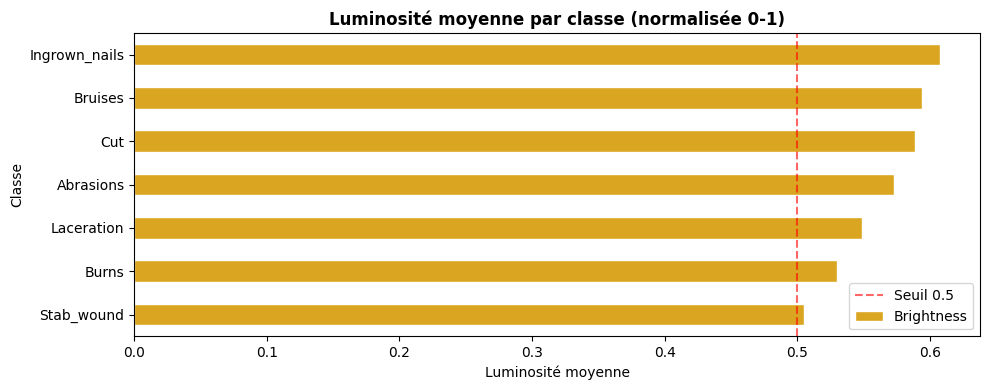

In [140]:
all_pixels = []
for img_arr in BD['img']:
    if img_arr.ndim == 3:
        all_pixels.append(img_arr.astype(np.float32) / 255.0)

all_pixels = np.concatenate([p.reshape(-1, 3) for p in all_pixels], axis=0)

mean_global = all_pixels.mean(axis=0)
std_global = all_pixels.std(axis=0)

print('\n📈 Statistiques globales des pixels (normalisés 0-1) :')
print(f"   • Moyenne  — R: {mean_global[0]:.4f} | G: {mean_global[1]:.4f} | B: {mean_global[2]:.4f}")
print(f"   • Écart-type — R: {std_global[0]:.4f} | G: {std_global[1]:.4f} | B: {std_global[2]:.4f}")

print('\n💡 Pour normaliser vos images dans le pipeline PyTorch, utilisez :')
print(f"   transforms.Normalize(mean={list(mean_global.round(4))}, std={list(std_global.round(4))})")

# Statistiques par classe
print('\n📊 Statistiques par classe (moyenne des pixels, canaux RGB normalisés) :')
stats_class = []
for cls in BD['Class'].unique():
    imgs_cls = BD[BD['Class'] == cls]['img'].tolist()
    pixels_cls = np.concatenate(
        [(img.astype(np.float32) / 255.0).reshape(-1, 3) for img in imgs_cls if img.ndim == 3],
        axis=0
    )
    stats_class.append({
        'Classe': cls,
        'R_mean': pixels_cls[:, 0].mean(),
        'G_mean': pixels_cls[:, 1].mean(),
        'B_mean': pixels_cls[:, 2].mean(),
        'R_std': pixels_cls[:, 0].std(),
        'G_std': pixels_cls[:, 1].std(),
        'B_std': pixels_cls[:, 2].std(),
    })

df_stats = pd.DataFrame(stats_class).set_index('Classe').round(4)
print(df_stats.to_string())

# Visualisation de la brightness moyenne
df_stats['Brightness'] = (df_stats['R_mean'] + df_stats['G_mean'] + df_stats['B_mean']) / 3

fig, ax = plt.subplots(figsize=(10, 4))
df_stats['Brightness'].sort_values().plot(kind='barh', color='goldenrod', ax=ax, edgecolor='white')
ax.set_title('Luminosité moyenne par classe (normalisée 0-1)', fontweight='bold')
ax.set_xlabel('Luminosité moyenne')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Seuil 0.5')
ax.legend()
plt.tight_layout()
plt.show()

#### Extraction du dataset

In [141]:
BD.to_pickle('data.pkl')
# Rechargement
test = pd.read_pickle('data.pkl')
test.head()
print(test.shape)

(431, 5)


In [142]:
# train_transforms = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),   # Flip horizontal aléatoire
#     transforms.RandomRotation(degrees=15),    # Rotation aléatoire
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # Variation de couleur
#     transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),  # Recadrage aléatoire
#     transforms.Resize(224,224),
#     # transforms.ToTensor(),                    # Conversion en tenseur
#     # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# ])

